**NOTICE:**
The U.S. Army Corps of Engineers, Risk Management Center (USACE-RMC) makes no guarantees about the results, or appropriateness of outputs, obtained from Numerics.

# 03. Time Series Forecasting
Time series analysis is the statistical study of data points collected sequentially over time. Unlike cross-sectional data where observations are assumed independent, time series data exhibit temporal dependence — today's observation is related to yesterday's, and tomorrow's will be related to today's. Understanding and modeling this dependence is essential for forecasting future values and understanding the dynamics of the system being studied. We investigate how BestFit deals with time dependent data and time series forecasting.

## What You'll Learn
In this notebook you will:
- Build `TimeSeries` objects from data
- Build TimeSeries models   
    - AR(p)
    - MA(q)
    - ARIMA(p,d,q)
    - ARIMAX(p,d,q,b)
- Validate this TimeSeries models
## Set Up

In [65]:
import pythonnet
pythonnet.load("coreclr")

import clr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import datetime as dt

from helper_functions import resolve_bestfit_dll, resolve_numerics_dll, convert_to_dotnet_array

clr.AddReference(str(resolve_numerics_dll()))
clr.AddReference(str(resolve_bestfit_dll()))

print("✓ Numerics loaded from:", resolve_numerics_dll())
print("✓ BestFit loaded from:", resolve_bestfit_dll())

from RMC.BestFit.Models import ARIMAX, AutoRegressive, MovingAverage, ARIMA, Transform, DataFrame
from RMC.BestFit.Estimation import MaximumLikelihood, OptimizationMethod
from RMC.BestFit.Analyses import ARAnalysis, MAAnalysis, ARIMAAnalysis, ARIMAXAnalysis

from Numerics.Data import TimeSeries, TimeInterval
from Numerics.Data.Statistics import Autocorrelation, Statistics, HypothesisTests, Correlation
from Numerics.Distributions import ChiSquared, Normal

from System import DateTime, Double
from System.Collections.Generic import List

print("✓ Imported namespaces successfully")

✓ Numerics loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\Numerics.dll
✓ BestFit loaded from: C:\GIT\RMC-BestFit\src\RMC.BestFit\bin\Debug\net10.0\RMC.BestFit.dll
✓ Imported namespaces successfully


## Why Time Series Analysis Matters

Consider a water resources engineer tasked with forecasting next month's streamflow for reservoir operations. Simply using the long-term average ignores valuable information: if this month's flow is unusually high, next month's flow is likely to also be above average (rivers don't jump randomly between extremes). Time series models capture this persistence, producing better forecasts than naive methods.

Time series analysis is fundamental to:

- **Streamflow forecasting**: Predict future flows for reservoir operations, water supply planning
- **Climate projections**: Model temperature, precipitation, and drought indices
- **Demand forecasting**: Predict water demand, electricity load, or economic variables
- **Quality control**: Detect anomalies in sensor data through residual monitoring
- **Understanding dynamics**: Quantify how quickly systems respond to perturbations

BestFit provides a comprehensive suite of time series models with both Maximum Likelihood (MLE) and Bayesian MCMC estimation, enabling full uncertainty quantification for forecasts.

## Block Series
We have covered how to create a DataFrame using largely ExactData that we populated directly in the DataFrame object. We can also use a TimeSeries object to create a DataFrame. The TimeSeries object is a Numerics' method that makes dealing with time dependant data easier. It contains the date of an observation along with the value of the observation. 

9 data points added to DataFrame.


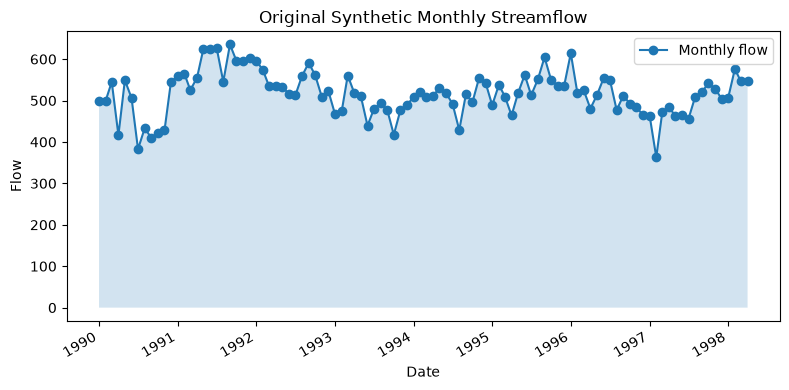

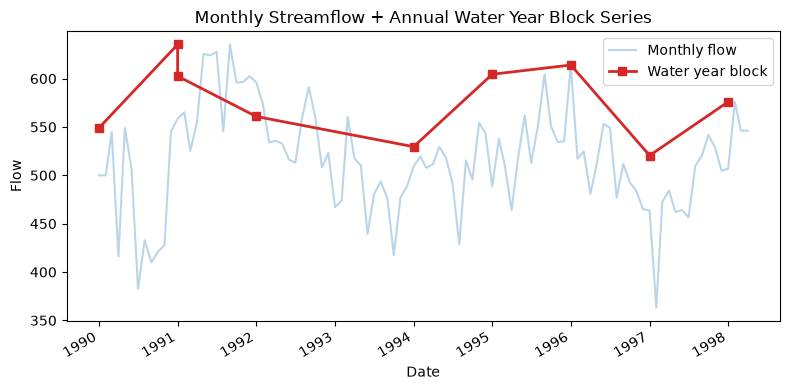

In [66]:
# Initialize an empty DataFrame
df = DataFrame()

# Generate synthetic monthly flow data
rng = np.random.default_rng(456)
y = np.zeros(100) # 100 months
y[0] = 500
y[1] = 500       # Initialize first 2 months to mean
for t in range(2, 100):
    eps = rng.normal(0, 50)
    y[t] = 500 + 0.5*(y[t-1] - 500) + 0.2*(y[t-2] - 500) + eps

monthly_flows = y

# Create TimeSeries from monthly streamflow data
start_date = DateTime(1990,1,1)
ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_flows))
df.CreateBlockSeries(ts)    # Add the TimeSeries to the DataFrame as a block series
print(df.ExactSeries.Count, "data points added to DataFrame.")

orig_dates = list(ts.IndexesToArray())    # returns array of DateTime
orig_values = list(ts.ValuesToArray())    # returns array of doubles

# Convert .NET DateTime to Python datetime
orig_py_dates = [
    dt.datetime(d.Year, d.Month, d.Day)
    for d in orig_dates
]

# Plot the original synthetic monthly streamflow data
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(orig_py_dates, orig_values, marker="o", linestyle="-", label="Monthly flow")
ax.fill_between(orig_py_dates, orig_values, alpha=0.2)
ax.set_xlabel("Date")
ax.set_ylabel("Flow")
ax.set_title("Original Synthetic Monthly Streamflow")
ax.legend()
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

# Now we will plot the block series (annual water year) on top of the original monthly streamflow data
block_dates = list(df.ExactSeries.IndicesToList())     # returns array of years (int)
block_values = list(df.ExactSeries.ValuesToList())     # returns array of doubles

# Convert to Python datetime for plotting
block_py_dates = [
    dt.datetime(d, 1, 1) # Convert to Jan 1 of each year for plotting
    for d in block_dates
]

fig, ax = plt.subplots(figsize=(8, 4))

# Original monthly flow data
ax.plot(orig_py_dates, orig_values, color="tab:blue", alpha=0.3, label="Monthly flow")

# Block series on top
ax.plot(block_py_dates,block_values,color="tab:red",marker="s",linewidth=2,linestyle="-",label="Water year block")
ax.set_xlabel("Date")
ax.set_ylabel("Flow")
ax.set_title("Monthly Streamflow + Annual Water Year Block Series")
ax.legend()
fig.autofmt_xdate()

plt.tight_layout()
plt.show()

Most of the methods in this notebook take TimeSeries objects directly, bypassing the need for a DataFrame, but it is still an important conversion to know.

## Core Concepts

Before diving into specific models, let's establish key concepts that underpin all time series analysis.

### Stationarity

A time series is stationary if its statistical properties (mean, variance, autocorrelation structure) don't change over time. Most classical time series models assume stationarity because:

1. Non-stationary series have time-varying parameters, making estimation ill-defined
2. Forecasts from non-stationary models can diverge to infinity
3. Standard statistical tests assume stationarity

**Weak stationarity** (the practical definition) requires:
- Constant mean: $E[Y_t] = \mu$ for all $t$
- Constant variance: $\text{Var}(Y_t) = \sigma^2$ for all $t$
- Autocovariance depends only on lag: $\text{Cov}(Y_t, Y_{t+h}) = \gamma(h)$ for all $t$

Many real-world series are non-stationary due to trends or seasonality. The ARIMA framework handles this by differencing the series to achieve stationarity before modeling.

### Autocorrelation

Autocorrelation measures the correlation between a time series and lagged versions of itself. The autocorrelation function (ACF) at lag $h$ is:

$$
\rho(h) = \frac{\text{Cov}(Y_t, Y_{t+h})}{\text{Var}(Y_t)} = \frac{\gamma(h)}{\gamma(0)}
$$

The ACF reveals the memory structure of the series:
- Fast decay: Short-memory process (AR models with small coefficients)
- Slow decay: Long-memory or near unit-root process
- Sharp cutoff: MA structure (ACF drops to zero after lag $q$)
- Sinusoidal pattern: Seasonal or cyclical component

The **partial autocorrelation function (PACF)** measures the correlation between $Y_t$ and $Y_{t+h}$ after removing the linear effect of intermediate lags $Y_{t+1}, \ldots, Y_{t+h-1}$. The PACF is crucial for identifying AR order:
- AR(p) process: PACF cuts off after lag $p$
- MA(q) process: PACF decays gradually

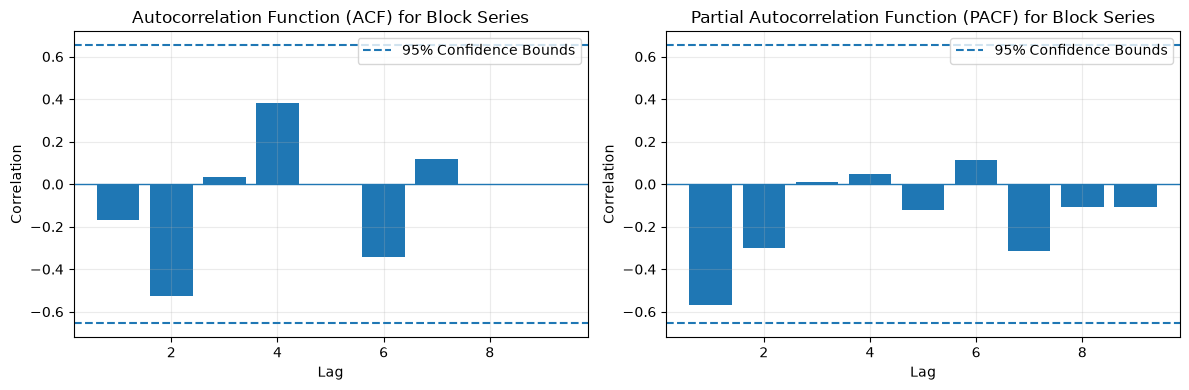

In [67]:
acf = Autocorrelation.Function(convert_to_dotnet_array(block_values),lagMax=10)
pacf = Autocorrelation.Function(convert_to_dotnet_array(block_values),lagMax=10, type = Autocorrelation.Type.Partial) # default type is correlation

lags = np.arange(1,10)

acf_vals = np.array([
    float(acf[int(i),1])
    for i in lags
])

pacf_vals = np.array([
    float(pacf[int(i),1])
    for i in lags
])

# Calculate 95% confidence bounds for ACF and PACF
bound = 1.96 / np.sqrt(len(block_values))

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].bar(lags,acf_vals)
ax[0].axhline(bound,linestyle="--", label="95% Confidence Bounds")
ax[0].axhline(-bound,linestyle="--", label="_nolegend_")
ax[0].axhline(0.0,linewidth=1)
ax[0].set_title("Autocorrelation Function (ACF) for Block Series")
ax[0].set_xlabel("Lag")
ax[0].set_ylabel("Correlation")
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].bar(lags,pacf_vals)
ax[1].axhline(bound,linestyle="--", label="95% Confidence Bounds")
ax[1].axhline(-bound,linestyle="--", label="_nolegend_")
ax[1].axhline(0.0,linewidth=1)
ax[1].set_title("Partial Autocorrelation Function (PACF) for Block Series")
ax[1].set_xlabel("Lag")
ax[1].set_ylabel("Correlation")
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.tight_layout()



### White Noise

White noise is a sequence of uncorrelated random variables with constant mean and variance:

$$
\varepsilon_t \stackrel{iid}{\sim} N(0, \sigma^2)
$$

White noise has:
- $\rho(0) = 1$ (correlation with itself)
- $\rho(h) = 0$ for $h \neq 0$ (no correlation at any lag)

The goal of time series modeling is to transform the observed series into white noise residuals. If residuals still show autocorrelation, the model is missing structure.

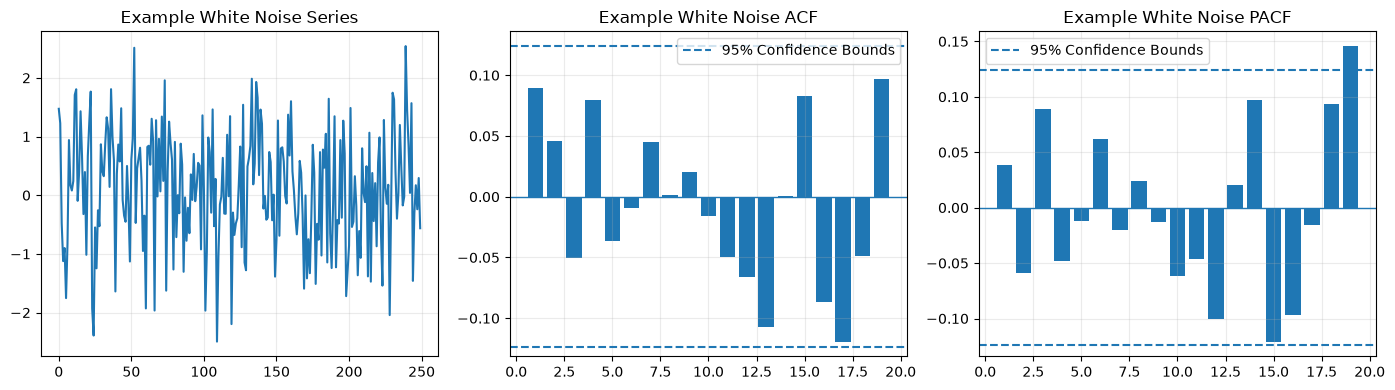

In [68]:
white_noise = list(Normal(0, 1).GenerateRandomValues(250,seed=12345))

wn_acf = Autocorrelation.Function(convert_to_dotnet_array(white_noise),lagMax=20)
wn_pacf = Autocorrelation.Function(convert_to_dotnet_array(white_noise),lagMax=20,type=Autocorrelation.Type.Partial) 

lags = np.arange(1,20)

acf_vals = np.array([
    float(wn_acf[int(i),1])
    for i in lags
])

pacf_vals = np.array([
    float(wn_pacf[int(i),1])
    for i in lags
])

# Calculate 95% confidence bounds for ACF and PACF
bound = 1.96 / np.sqrt(len(white_noise))

fig, ax = plt.subplots(1,3,figsize=(14,4))

ax[0].plot(white_noise)
ax[0].set_title("Example White Noise Series")
ax[0].grid(alpha=0.25)

ax[1].bar(lags,acf_vals)
ax[1].axhline(bound, linestyle="--", label="95% Confidence Bounds")
ax[1].axhline(-bound, linestyle="--", label="_nolegend_")
ax[1].axhline(0.0, linewidth=1)
ax[1].set_title("Example White Noise ACF")
ax[1].grid(alpha=0.25)
ax[1].legend()

ax[2].bar(lags,pacf_vals)
ax[2].axhline(bound, linestyle="--", label="95% Confidence Bounds")
ax[2].axhline(-bound, linestyle="--", label="_nolegend_")
ax[2].axhline(0.0, linewidth=1)
ax[2].set_title("Example White Noise PACF")
ax[2].grid(alpha=0.25)
ax[2].legend()

plt.tight_layout()

### The Backshift Operator

The backshift (lag) operator $L$ simplifies notation:

$$
L Y_t = Y_{t-1}, \quad L^2 Y_t = Y_{t-2}, \quad L^k Y_t = Y_{t-k}
$$

The **difference operator** is:

$$
\Delta Y_t = Y_t - Y_{t-1} = (1 - L) Y_t
$$

Higher-order differences:

$$
\Delta^2 Y_t = \Delta(\Delta Y_t) = Y_t - 2Y_{t-1} + Y_{t-2} = (1-L)^2 Y_t
$$

Using these operators, model equations become compact polynomial expressions that reveal the mathematical structure.

## Model Overview

BestFit implements four primary time series model classes that we will explore:

| Model | Class | Parameters | When to Use |
|-------|-------|------------|-------------|
| AR(p) | `AutoRegressive` | $p + 2$ | Gradual ACF decay, sharp PACF cutoff |
| MA(q) | `MovingAverage` | $q + 2$ | Sharp ACF cutoff, gradual PACF decay |
| ARIMA(p,d,q) | `ARIMA` | $p + q + 2$ | Non-stationary series needing differencing |
| ARIMAX(p,d,q,b) | `ARIMAX` | $p + q + K + 2+$ | External predictors available |


## Autoregressive Model — AR(p)

The autoregressive model is the workhorse of time series analysis. It expresses the current value as a linear combination of past values plus random noise — essentially a regression of the series on its own lagged values. Imagine predicting tomorrow's river flow. If today's flow is high, tomorrow's is likely high too (persistence). If yesterday's was also high, that provides additional information. An AR model formalizes this: predict today using a weighted combination of recent past values. 

The "order" $p$ specifies how many past values to include. An AR(1) uses only yesterday; AR(2) uses yesterday and the day before; and so on.

### Mathematical Formulation

The AR(p) model is defined as [[1]](#1):

$$
Y_t = \mu + \sum_{i=1}^{p} \phi_i (Y_{t-i} - \mu) + \varepsilon_t
$$

where:
- $Y_t$ is the observation at time $t$
- $\mu$ is the process mean (intercept)
- $\phi_1, \phi_2, \ldots, \phi_p$ are the AR coefficients
- $\varepsilon_t \stackrel{iid}{\sim} N(0, \sigma^2)$ is white noise

An equivalent formulation that's often more intuitive:

$$
Y_t = c + \phi_1 Y_{t-1} + \phi_2 Y_{t-2} + \ldots + \phi_p Y_{t-p} + \varepsilon_t
$$

where $c = \mu(1 - \phi_1 - \phi_2 - \ldots - \phi_p)$ is a constant term.

Using the backshift operator:

$$
\Phi(L)(Y_t - \mu) = \varepsilon_t
$$

where $\Phi(L) = 1 - \phi_1 L - \phi_2 L^2 - \ldots - \phi_p L^p$ is the **AR polynomial**.

### Parameters

For an AR(p) model with intercept:
- $\mu$: Process mean (intercept)
- $\phi_1, \phi_2, \ldots, \phi_p$: AR coefficients
- $\sigma$: Error standard deviation

Total parameters: $p + 2$ (with intercept) or $p + 1$ (without intercept)

### Stationarity Conditions

For a stationary AR process, all roots of the characteristic polynomial must lie **outside** the unit circle [[1]](#1):

$$
\Phi(z) = 1 - \phi_1 z - \phi_2 z^2 - \ldots - \phi_p z^p = 0
$$

This ensures the process doesn't explode to infinity.

Simplified conditions for low orders:
- AR(1): $|\phi_1| < 1$
- AR(2): $\phi_1 + \phi_2 < 1$, $\phi_2 - \phi_1 < 1$, $|\phi_2| < 1$

A sufficient (but not necessary) general condition: $\sum_{i=1}^{p} |\phi_i| < 1$

Interpretation of coefficients:
- $\phi_1 > 0$: Positive persistence (high values followed by high values)
- $\phi_1 < 0$: Oscillating behavior (high values followed by low values)
- $\phi_1 \approx 1$: Near unit root, very persistent (slow mean reversion)
- $\phi_1 \approx 0$: Little dependence on immediate past

### ACF and PACF Patterns

The AR(p) process has distinctive correlation patterns:

| Statistic | Pattern |
|-----------|---------|
| ACF | Exponential decay (or damped sinusoid for complex roots) |
| PACF | Cuts off sharply after lag $p$ |

This PACF cutoff is the key diagnostic for identifying AR order.

### Likelihood Function

The conditional log-likelihood, conditioning on the first $p$ observations, is [[2]](#2):

$$
\ell(\theta) = -\frac{n-p}{2}\log(2\pi) - (n-p)\log(\sigma) - \frac{1}{2\sigma^2}\sum_{t=p+1}^{n} \varepsilon_t^2
$$

where the residuals are:

$$
\varepsilon_t = Y_t - \mu - \sum_{i=1}^{p} \phi_i (Y_{t-i} - \mu)
$$

### Implementation Example
Let's fit an AR(2) model to monthly streamflow data

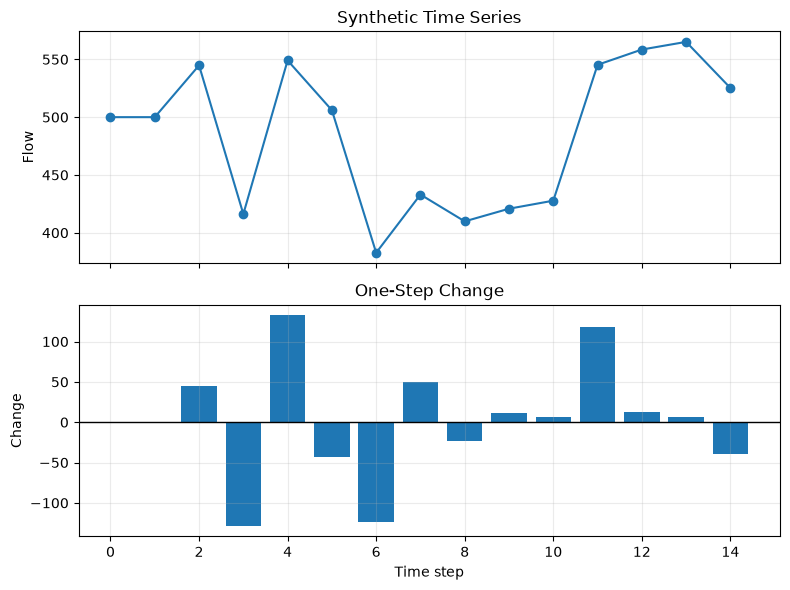

In [69]:
# Generate synthetic monthly flow data
rng = np.random.default_rng(456)
y = np.zeros(15) # 15 months
y[0] = 500
y[1] = 500       # Initialize first 2 months to mean
for t in range(2, 15):
    eps = rng.normal(0, 50)
    y[t] = 500 + 0.5*(y[t-1] - 500) + 0.2*(y[t-2] - 500) + eps

monthly_flows = y

fig, ax = plt.subplots(2,1,figsize=(8,6),sharex=True)
ax[0].plot(np.arange(len(y)), y, marker="o")
ax[0].set_ylabel("Flow"); ax[0].set_title("Synthetic Time Series")
ax[0].grid(alpha=.25)

ax[1].bar(np.arange(1,len(y)), np.diff(y))
ax[1].axhline(0,color="black",lw=1)
ax[1].set_xlabel("Time step"); ax[1].set_ylabel("Change")
ax[1].set_title("One-Step Change")
ax[1].grid(alpha=.25)
plt.tight_layout()

In [70]:
# Create time series from monthly streamflow data
start_date = DateTime(1990,1,1)
ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_flows))

# Create AR(2) model
ar_model = AutoRegressive(ts, order=2, includeIntercept=True)
ar_model.UseDefaultTrainingSteps = True
ar_model.UseJeffreysRuleForScale = True
ar_model.TrainingTimeSteps = ts.Count

# Perform MLE estimation using MaximumLikelihood class
ar_mle = MaximumLikelihood(ar_model)
ar_mle.Estimate()

if ar_mle.IsEstimated:
    ar_model.SetParameterValues(ar_mle.BestParameterSet.Values)

    # Parameter indices for AR(2) with intercept: [0]=μ, [1]=φ₁, [2]=φ₂, [3]=σ
    print(f"Mean (μ):     {ar_model.Parameters[0].Value:.2f}")
    print(f"AR(1) (φ₁):   {ar_model.Parameters[1].Value:.4f}")
    print(f"AR(2) (φ₂):   {ar_model.Parameters[2].Value:.4f}")
    print(f"Sigma (σ):    {ar_model.Parameters[3].Value:.4f}")

Mean (μ):     485.56
AR(1) (φ₁):   0.3277
AR(2) (φ₂):   0.0887
Sigma (σ):    61.3576


For Bayesian estimation with uncertainty quantification and forecasting:

In [71]:
# Create analysis object
ar_analysis = ARAnalysis(ar_model)
ar_analysis.BayesianAnalysis.PRNGSeed = 1234
ar_analysis.BayesianAnalysis.Iterations = 10000
ar_analysis.BayesianAnalysis.WarmupIterations = 5000
ar_analysis.ForecastingTimeSteps = 12       # Forecast 12 months ahead

# Run MCMC
ar_analysis.RunAsync().Wait()

# Access posterior summaries
ar_results = ar_analysis.BayesianAnalysis.Results
print("\nPosterior Summary:")
print(f"{"Parameter":<12} {"Mean":>10} {"Std Dev":>10} {"2.5%":>10} {"97.5%":>10}")
for i in range(ar_model.Parameters.Count):
    stats = ar_results.ParameterResults[i].SummaryStatistics
    print(f"{ar_model.Parameters[i].Name:<12} {stats.Mean:>10.4f} {stats.StandardDeviation:>10.4f} " +
                      f"{stats.LowerCI:>10.4f} {stats.UpperCI:>10.4f}")

# Access forecasts with uncertainty
ar_forecasts = ar_analysis.AnalysisResults
print("\nForecasts:")
print(f"{"Month":<8} {"Forecast":>12} {"Lower 95%":>12} {"Upper 95%":>12}")
for h in range(12):
    mode = ar_forecasts.MeanCurve[h]
    # lower = forecasts.LowerCurve[h]           these don't exist??
    # upper = forecasts.UpperCurve[h]
    lower = ar_forecasts.ConfidenceIntervals[h, 1]      # need to double check definition of these....
    upper = ar_forecasts.ConfidenceIntervals[h, 2]
    print(f"{h + 1:<8} {mode:>12.1f} {lower:>12.1f} {upper:>12.1f}")


Posterior Summary:
Parameter          Mean    Std Dev       2.5%      97.5%
Intercept (μ)  1228.0763  1758.1192   241.2611  5603.4861
AR (φ₁)          0.5002     0.3320    -0.0520     1.0371
AR (φ₂)          0.2873     0.3484    -0.3028     0.8494
Scale (σ)       76.8175    18.5967    52.8359   111.2623

Forecasts:
Month        Forecast    Lower 95%    Upper 95%
1               500.0        500.0        500.0
2               500.0        500.0        500.0
3               498.8        365.4        629.3
4               523.0        389.9        661.1
5               471.2        323.6        619.7
6               499.6        353.9        646.3
7               516.4        376.9        654.9
8               441.5        293.1        588.3
9               431.8        292.4        572.5
10              434.8        297.7        573.1
11              434.6        301.1        573.1
12              440.4        308.8        575.1


### Practical Considerations

Choosing the order $p$:
1. Plot the PACF — it should cut off after lag $p$
2. Start with low orders (1-3) for most applications
3. Use information criteria (AIC, BIC) to compare models
4. Prefer parsimony — simpler models often forecast better

Common issues:
- Near unit root ($\phi_1 \approx 1$): Consider differencing instead
- Seasonal patterns: PACF may show spikes at seasonal lags; consider seasonal terms or Fourier basis
- Outliers: Can inflate variance estimates; consider robust methods or data cleaning

12


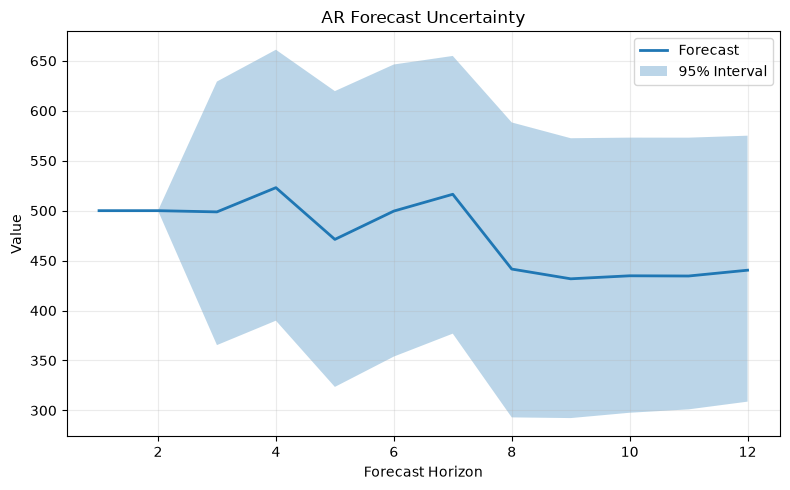

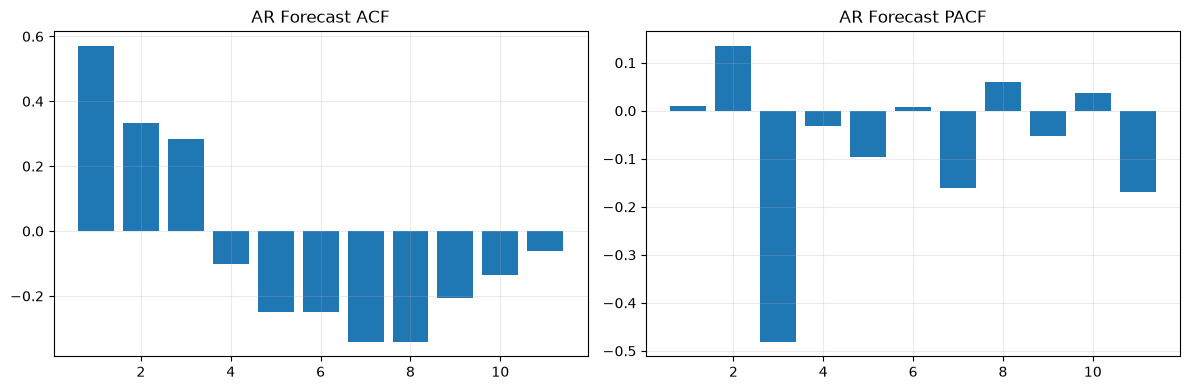

In [72]:
print(ar_analysis.ForecastingTimeSteps)

ar_forecast_steps = np.arange(1,ar_analysis.ForecastingTimeSteps + 1)

ar_forecast_mode = np.array([
    ar_forecasts.MeanCurve[i]
    for i in range(
        ar_analysis.ForecastingTimeSteps
    )
])

ar_forecast_lower = np.array([
    ar_forecasts.ConfidenceIntervals[i,1]
    for i in range(
        ar_analysis.ForecastingTimeSteps
    )
])

ar_forecast_upper = np.array([
    ar_forecasts.ConfidenceIntervals[i,2]
    for i in range(
        ar_analysis.ForecastingTimeSteps
    )
])

plt.figure(figsize=(8,5))
plt.plot(ar_forecast_steps,ar_forecast_mode,linewidth=2,label="Forecast")
plt.fill_between(ar_forecast_steps,ar_forecast_lower,ar_forecast_upper,alpha=0.3,label="95% Interval")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.title("AR Forecast Uncertainty")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

ar_acf = Autocorrelation.Function(convert_to_dotnet_array(ar_forecast_mode),lagMax=12)
ar_pacf = Autocorrelation.Function(convert_to_dotnet_array(ar_forecast_mode),lagMax=12,type=Autocorrelation.Type.Partial)
lags = np.arange(1,12)

ar_acf_vals = np.array([
    float(ar_acf[int(i),1])
    for i in lags
])

ar_pacf_vals = np.array([
    float(ar_pacf[int(i),1])
    for i in lags
])

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].bar(lags,ar_acf_vals)
ax[0].set_title("AR Forecast ACF")
ax[0].grid(alpha=0.25)

ax[1].bar(lags,ar_pacf_vals)
ax[1].set_title("AR Forecast PACF")
ax[1].grid(alpha=0.25)

plt.tight_layout()


## Moving Average Model — MA(q)

The moving average model expresses the current value as a linear combination of current and past random shocks (error terms). While AR models capture persistence through lagged observations, MA models capture persistence through the lingering effects of past innovations. Imagine a river where upstream rainfall events cause flow perturbations that take several days to pass the gauge. Today's flow depends on today's rainfall plus echoes of the past few days' rainfall. An MA model captures this: the current value depends on the current shock plus weighted past shocks.

The "order" $q$ specifies how many past shocks influence the current value. An MA(1) uses only today's and yesterday's shocks; MA(2) adds the day before; and so on.

### Mathematical Formulation

The MA(q) model is defined as [[1]](#1):

$$
Y_t = \mu + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

where:
- $Y_t$ is the observation at time $t$
- $\mu$ is the process mean
- $\theta_1, \theta_2, \ldots, \theta_q$ are the MA coefficients
- $\varepsilon_t \stackrel{iid}{\sim} N(0, \sigma^2)$ is white noise

Using the backshift operator:

$$
Y_t - \mu = \Theta(L) \varepsilon_t
$$

where $\Theta(L) = 1 + \theta_1 L + \theta_2 L^2 + \ldots + \theta_q L^q$ is the **MA polynomial**.

### Parameters

For an MA(q) model with intercept:
- $\mu$: Process mean
- $\theta_1, \theta_2, \ldots, \theta_q$: MA coefficients
- $\sigma$: Error standard deviation

Total parameters: $q + 2$ (with intercept) or $q + 1$ (without)

### Invertibility Conditions

For an **invertible** MA process, all roots of the MA polynomial must lie outside the unit circle [[1]](#1):

$$
\Theta(z) = 1 + \theta_1 z + \theta_2 z^2 + \ldots + \theta_q z^q = 0
$$

Simplified conditions:
- **MA(1)**: $|\theta_1| < 1$

Invertibility ensures:
1. A unique model representation (non-invertible models have equivalent invertible forms)
2. The MA process can be written as an infinite-order AR process
3. Past shocks can be recovered from observed data

### ACF and PACF Patterns

The MA(q) process has distinctive correlation patterns:

| Statistic | Pattern |
|-----------|---------|
| ACF | Cuts off sharply after lag $q$ |
| PACF | Exponential decay (or damped sinusoid) |

This ACF cutoff is the key diagnostic for identifying MA order — it's the opposite pattern from AR.

### Likelihood Function

The exact likelihood for MA models requires iterative computation of residuals. Given parameters, residuals are computed recursively:

$$
\varepsilon_t = Y_t - \mu - \sum_{j=1}^{\min(t-1, q)} \theta_j \varepsilon_{t-j}
$$

with initialization $\varepsilon_0 = \varepsilon_{-1} = \ldots = 0$.

The conditional log-likelihood is:

$$
\ell(\theta) = -\frac{n}{2}\log(2\pi) - n\log(\sigma) - \frac{1}{2\sigma^2}\sum_{t=1}^{n} \varepsilon_t^2
$$

### Forecasting Properties

MA(q) forecasts converge to the mean $\mu$ after $q$ steps ahead:

- **Short horizon** ($h \leq q$): Forecast uses recent shocks

$$
\hat{Y}_{n+h|n} = \mu + \sum_{j=h}^{q} \theta_j \varepsilon_{n+h-j}
$$

- **Long horizon** ($h > q$): Forecast equals the mean

$$
\hat{Y}_{n+h|n} = \mu
$$

This makes MA models suitable for **transient shocks** — perturbations that affect the system for exactly $q$ periods then disappear.

### Implementation Example
Let's fit a MA(2) model to the same monthly stream flow data.

MLE Estimates:
Mean (μ):     486.69
MA(1) (θ₁):   0.2888
MA(2) (θ₂):   0.1446
Sigma (σ):    57.6676

Bayesian Estimates:
Parameter          Mean    Std Dev       2.5%      97.5%
Intercept (μ)   504.9077    27.1173   458.7491   541.3196
MA (θ₁)         -0.1622     0.4765    -0.7868     0.6210
MA (θ₂)          0.7168     0.9268    -1.2402     1.9294
Scale (σ)       58.7570    16.9217    35.4713    88.9936

Forecasts:
Month        Forecast    Lower 95%    Upper 95%
1               504.5        389.7        607.3
2               512.5        396.5        617.9
3               497.5        394.5        598.9
4               471.4        368.3        597.4
5               526.7        366.5        669.5
6               507.3        386.3        623.3
7               457.4        327.7        587.5
8               493.9        357.4        619.6
9               465.7        353.4        577.7
10              441.1        333.0        564.0
11              447.3        335.5        569.9
12   

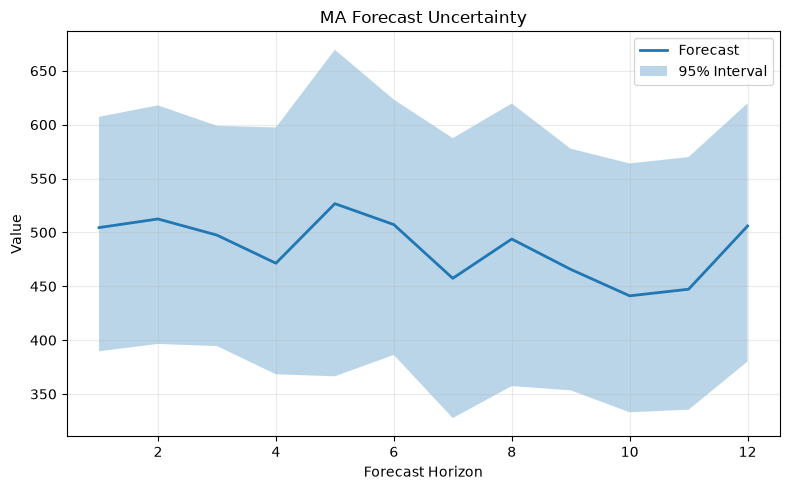

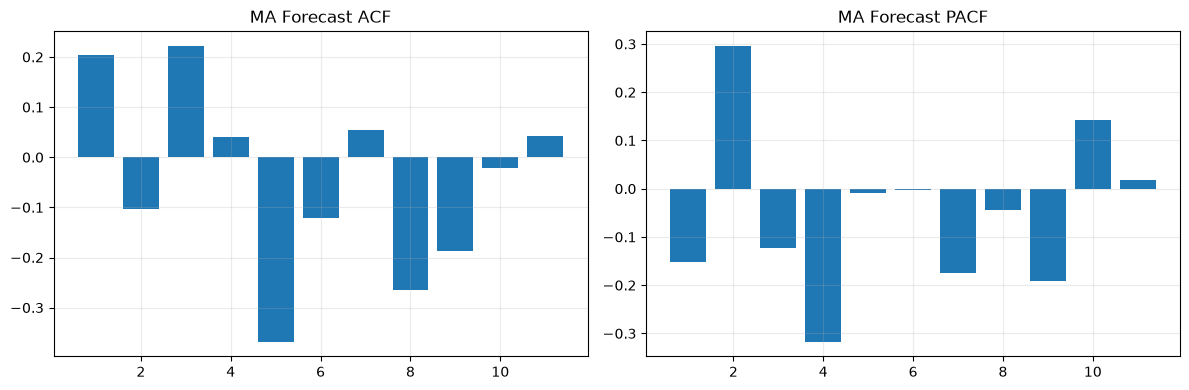

In [73]:
# Create a MA(2) model
ma_model = MovingAverage(ts, order=2, includeIntercept=True)
ma_model.UseDefaultTrainingSteps = False
ma_model.UseJeffreysRuleForScale = True
ma_model.TrainingTimeSteps = ts.Count

# MLE estimation using MaximumLikelihood class
ma_mle = MaximumLikelihood(ma_model)
ma_mle.Estimate()

if ma_mle.IsEstimated:
    ma_model.SetParameterValues(ma_mle.BestParameterSet.Values)
    print("MLE Estimates:")
    # Parameter indices for MA(2) with intercept: [0]=μ, [1]=θ₁, [2]=θ₂, [3]=σ
    print(f"Mean (μ):     {ma_model.Parameters[0].Value:.2f}")
    print(f"MA(1) (θ₁):   {ma_model.Parameters[1].Value:.4f}")
    print(f"MA(2) (θ₂):   {ma_model.Parameters[2].Value:.4f}")
    print(f"Sigma (σ):    {ma_model.Parameters[3].Value:.4f}")

# Bayesian estimation
ma_analysis = MAAnalysis(ma_model)
ma_analysis.BayesianAnalysis.PRNGSeed = 1234
ma_analysis.BayesianAnalysis.Iterations = 10000
ma_analysis.BayesianAnalysis.WarmupIterations = 5000
ma_analysis.ForecastingTimeSteps = 12
ma_analysis.RunAsync().Wait()

# Access posterior summaries
ma_results = ma_analysis.BayesianAnalysis.Results

print("\nBayesian Estimates:")
print(f"{"Parameter":<12} {"Mean":>10} {"Std Dev":>10} {"2.5%":>10} {"97.5%":>10}")
for i in range(ma_model.Parameters.Count):
    stats = ma_results.ParameterResults[i].SummaryStatistics
    print(f"{ma_model.Parameters[i].Name:<12} {stats.Mean:>10.4f} {stats.StandardDeviation:>10.4f} " +
                      f"{stats.LowerCI:>10.4f} {stats.UpperCI:>10.4f}")

# Access forecasts with uncertainty
ma_forecasts = ma_analysis.AnalysisResults
print("\nForecasts:")
print(f"{"Month":<8} {"Forecast":>12} {"Lower 95%":>12} {"Upper 95%":>12}")
for h in range(12):
    mode = ma_forecasts.MeanCurve[h]
    # lower = ma_forecasts.LowerCurve[h]           these don't exist??
    # upper = ma_forecasts.UpperCurve[h]
    lower = ma_forecasts.ConfidenceIntervals[h, 1]      # need to double check definition of these....
    upper = ma_forecasts.ConfidenceIntervals[h, 2]
    print(f"{h + 1:<8} {mode:>12.1f} {lower:>12.1f} {upper:>12.1f}")

ma_forecast_steps = np.arange(1,ma_analysis.ForecastingTimeSteps + 1)

ma_forecast_mode = np.array([
    ma_forecasts.MeanCurve[i]
    for i in range(
        ma_analysis.ForecastingTimeSteps
    )
])

ma_forecast_lower = np.array([
    ma_forecasts.ConfidenceIntervals[i,1]
    for i in range(
        ma_analysis.ForecastingTimeSteps
    )
])

ma_forecast_upper = np.array([
    ma_forecasts.ConfidenceIntervals[i,2]
    for i in range(
        ma_analysis.ForecastingTimeSteps
    )
])

plt.figure(figsize=(8,5))
plt.plot(ma_forecast_steps,ma_forecast_mode,linewidth=2,label="Forecast")
plt.fill_between(ma_forecast_steps,ma_forecast_lower,ma_forecast_upper,alpha=0.3,label="95% Interval")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.title("MA Forecast Uncertainty")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

# Add ACF and PACF graph?
ma_acf = Autocorrelation.Function(convert_to_dotnet_array(ma_forecast_mode),lagMax=12)
ma_pacf = Autocorrelation.Function(convert_to_dotnet_array(ma_forecast_mode),lagMax=12,type=Autocorrelation.Type.Partial)
lags = np.arange(1,12)

ma_acf_vals = np.array([
    float(ma_acf[int(i),1])
    for i in lags
])

ma_pacf_vals = np.array([
    float(ma_pacf[int(i),1])
    for i in lags
])

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].bar(lags,ma_acf_vals)
ax[0].set_title("MA Forecast ACF")
ax[0].grid(alpha=0.25)

ax[1].bar(lags,ma_pacf_vals)
ax[1].set_title("MA Forecast PACF")
ax[1].grid(alpha=0.25)

plt.tight_layout()


## ARIMA Model — ARIMA(p,d,q)

ARIMA (AutoRegressive Integrated Moving Average) combines differencing with ARMA modeling to handle non-stationary series. Many real-world series exhibit trends or stochastic wandering that violates stationarity — ARIMA handles this by differencing the series before applying AR and MA components [[1]](#1). Consider a stock price that wanders randomly over time (a "random walk"). The price level is non-stationary, but the daily *changes* (differences) might be stationary noise. ARIMA works by:
1. Differencing the series $d$ times to achieve stationarity
2. Fitting an ARMA(p,q) model to the differenced series
3. Integrating forecasts back to the original scale

The "I" in ARIMA stands for "Integrated" — the opposite of differencing.

### Mathematical Formulation

The ARIMA(p,d,q) model is defined as:

$$
\Phi(L)(1-L)^d (Y_t - \mu) = \Theta(L) \varepsilon_t
$$

where:
- $(1-L)^d$ is the differencing operator applied $d$ times
- $\Phi(L)$ is the AR polynomial
- $\Theta(L)$ is the MA polynomial

Let $W_t = \Delta^d Y_t = (1-L)^d Y_t$ be the differenced series. Then:

$$
W_t = \mu + \sum_{i=1}^{p} \phi_i (W_{t-i} - \mu) + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

### Differencing

The differencing operation transforms the series:

- First difference ($d=1$): $\Delta Y_t = Y_t - Y_{t-1}$ — removes linear trend
- Second difference ($d=2$): $\Delta^2 Y_t = \Delta(\Delta Y_t) = Y_t - 2Y_{t-1} + Y_{t-2}$ — removes quadratic trend

**Effect on series length:** After $d$ differences, $n$ observations become $n-d$ observations.

### When to Difference

Differencing is appropriate when the series shows:
- Trending behavior: Systematic upward or downward movement
- Unit root: ACF decays very slowly (series is very persistent)
- Non-constant mean: Mean appears to change over time

**Warning:** Over-differencing can introduce artificial patterns. If the differenced series shows negative autocorrelation at lag 1, you may have over-differenced.

### Parameters

For an ARIMA(p,d,q) model:
- $\mu$: Mean of the differenced series (drift term if $d > 0$)
- $\phi_1, \ldots, \phi_p$: AR coefficients
- $\theta_1, \ldots, \theta_q$: MA coefficients
- $\sigma$: Error standard deviation

Total parameters: $p + q + 2$ (with intercept)

### Likelihood

Computed on the differenced series $W_t = \Delta^d Y_t$ using the ARMA likelihood:

$$
\ell(\theta) = -\frac{n-d-m}{2}\log(2\pi) - (n-d-m)\log(\sigma) - \frac{1}{2\sigma^2}\sum_{t=m+1}^{n-d} \varepsilon_t^2
$$

where $m = \max(p, q)$ accounts for conditioning.

### Implementation Example

Now we will fit an ARIMA(1,1,1) model (differenced AR(1) with MA(1) errors) on our monthly streamflow data.

MLE Estimates:
Drift (μ):    485.6019
AR(1) (φ₁):   0.3570
Sigma (σ):   59.3868

Bayesian Estimates:
Parameter          Mean    Std Dev       2.5%      97.5%
Intercept (μ)   848.0590  1269.0167   317.8369  2912.5180
AR (φ₁)          0.6280     0.3344     0.0468     1.0341
Scale (σ)       71.6218    16.6710    50.1262   102.2206

Forecasts:
Month        Forecast    Lower 95%    Upper 95%
1               500.0        500.0        500.0
2               495.5        372.3        615.8
3               496.6        371.9        621.5
4               524.9        400.3        656.0
5               443.0        314.1        571.0
6               526.2        398.4        656.4
7               499.0        376.1        625.2
8               422.3        287.0        556.0
9               453.4        326.1        579.4
10              439.8        309.8        569.3
11              446.0        319.8        571.5
12              450.9        320.8        575.1
13              524.7        398.4

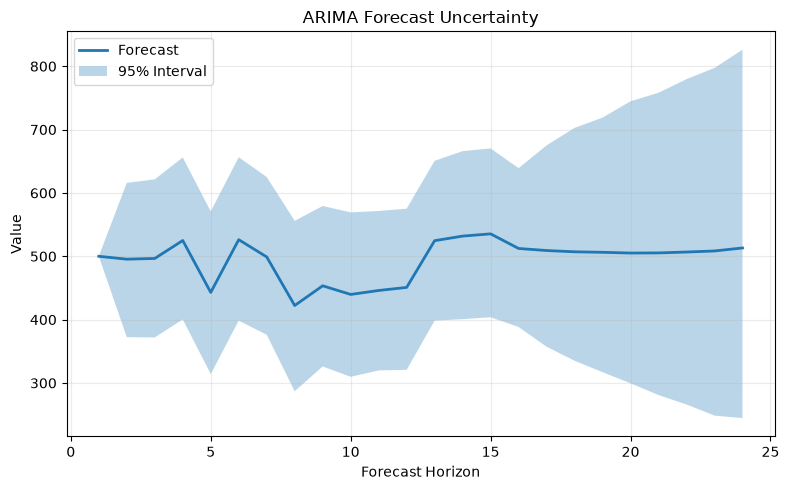

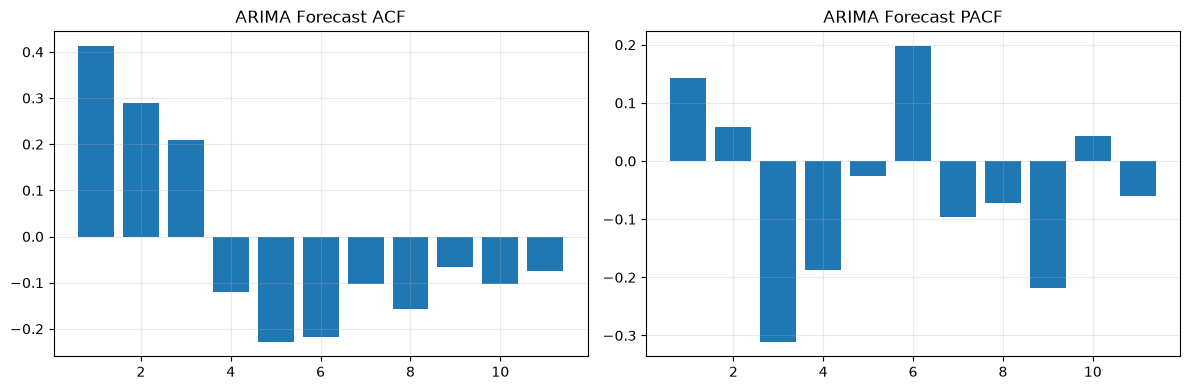

In [74]:
# Create ARIMA(1,1,1) model
ai_model = ARIMA(ts, AROrderP=1, DiffOrderD=1, MAOrderQ=1, IncludeIntercept=True, UseDefaultTrainingSteps=False)
ai_model.TrainingTimeSteps = ts.Count

# MLE estimation using MaximumLikelihood class
ai_mle = MaximumLikelihood(ai_model)
ai_mle.Estimate()

if ai_mle.IsEstimated:
    ai_model.SetParameterValues(ai_mle.BestParameterSet.Values)
    print("MLE Estimates:")
    # Parameter indices for ARIMA(1,1,1) with intercept: [0]=μ, [1]=φ₁, [2]=σ
    print(f"Drift (μ):    {ai_model.Parameters[0].Value:.4f}")
    print(f"AR(1) (φ₁):   {ai_model.Parameters[1].Value:.4f}")
    print(f"Sigma (σ):   {ai_model.Parameters[2].Value:.4f}")

ai_analysis = ARIMAAnalysis(ai_model)
ai_analysis.BayesianAnalysis.PRNGSeed = 1234
ai_analysis.BayesianAnalysis.Iterations = 10000
ai_analysis.WarmupIterations = 5000
ai_analysis.ForecastingTimeSteps = 24   # 24 month forecast

ai_analysis.RunAsync().Wait()
# Access posterior summaries
ai_results = ai_analysis.BayesianAnalysis.Results

print("\nBayesian Estimates:")
print(f"{"Parameter":<12} {"Mean":>10} {"Std Dev":>10} {"2.5%":>10} {"97.5%":>10}")
for i in range(ai_model.Parameters.Count):
    stats = ai_results.ParameterResults[i].SummaryStatistics
    print(f"{ai_model.Parameters[i].Name:<12} {stats.Mean:>10.4f} {stats.StandardDeviation:>10.4f} " +
                      f"{stats.LowerCI:>10.4f} {stats.UpperCI:>10.4f}")

# Access forecasts with uncertainty
ai_forecasts = ai_analysis.AnalysisResults
print("\nForecasts:")
print(f"{"Month":<8} {"Forecast":>12} {"Lower 95%":>12} {"Upper 95%":>12}")
for h in range(24):
    mode = ai_forecasts.MeanCurve[h]
    # lower = ai_forecasts.LowerCurve[h]           these don't exist??
    # upper = ai_forecasts.UpperCurve[h]
    lower = ai_forecasts.ConfidenceIntervals[h, 1]      # need to double check definition of these....
    upper = ai_forecasts.ConfidenceIntervals[h, 2]
    print(f"{h + 1:<8} {mode:>12.1f} {lower:>12.1f} {upper:>12.1f}")


ai_forecast_steps = np.arange(1,ai_analysis.ForecastingTimeSteps + 1)

ai_forecast_mode = np.array([
    ai_forecasts.MeanCurve[i]
    for i in range(
        ai_analysis.ForecastingTimeSteps
    )
])

ai_forecast_lower = np.array([
    ai_forecasts.ConfidenceIntervals[i,1]
    for i in range(
        ai_analysis.ForecastingTimeSteps
    )
])

ai_forecast_upper = np.array([
    ai_forecasts.ConfidenceIntervals[i,2]
    for i in range(
        ai_analysis.ForecastingTimeSteps
    )
])

plt.figure(figsize=(8,5))
plt.plot(ai_forecast_steps,ai_forecast_mode,linewidth=2,label="Forecast")
plt.fill_between(ai_forecast_steps,ai_forecast_lower,ai_forecast_upper,alpha=0.3,label="95% Interval")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.title("ARIMA Forecast Uncertainty")
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()

# Add ACF and PACF graph?
ai_acf = Autocorrelation.Function(convert_to_dotnet_array(ai_forecast_mode),lagMax=12)
ai_pacf = Autocorrelation.Function(convert_to_dotnet_array(ai_forecast_mode),lagMax=12,type=Autocorrelation.Type.Partial)
lags = np.arange(1,12)

ai_acf_vals = np.array([
    float(ai_acf[int(i),1])
    for i in lags
])

ai_pacf_vals = np.array([
    float(ai_pacf[int(i),1])
    for i in lags
])

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].bar(lags,ai_acf_vals)
ax[0].set_title("ARIMA Forecast ACF")
ax[0].grid(alpha=0.25)

ax[1].bar(lags,ai_pacf_vals)
ax[1].set_title("ARIMA Forecast PACF")
ax[1].grid(alpha=0.25)

plt.tight_layout()



### Special Cases

| Model | ARIMA Notation | Description |
|-------|---------------|-------------|
| White noise | ARIMA(0,0,0) | No structure, just noise |
| Random walk | ARIMA(0,1,0) | $Y_t = Y_{t-1} + \varepsilon_t$ |
| Random walk with drift | ARIMA(0,1,0) + intercept | $Y_t = c + Y_{t-1} + \varepsilon_t$ |
| AR(p) | ARIMA(p,0,0) | Autoregressive only |
| MA(q) | ARIMA(0,0,q) | Moving average only |
| ARMA(p,q) | ARIMA(p,0,q) | Mixed, no differencing |


## ARIMAX Model — ARIMAX(p,d,q,b)

ARIMAX extends ARIMA by incorporating **exogenous (external) predictor variables**. When external factors influence the response — climate indices affecting streamflow, economic indicators affecting demand, upstream flows affecting downstream gauges — ARIMAX captures both the internal dynamics and external effects [[3]](#3). Predicting reservoir inflow using only past inflows ignores valuable information: upstream precipitation, snowpack, temperature. ARIMAX includes these external predictors while still modeling the temporal dynamics of inflow itself.

The model separates two sources of predictability:
1. **Internal dynamics**: How the series depends on its own past (AR/MA terms)
2. **External effects**: How external predictors influence the series (regression terms)

### Mathematical Formulation

The ARIMAX model is:

$$
Y_t = \mu + \gamma(t) + \psi(t) + \sum_{k=1}^{K} \beta_k X_{k,t-b} + \sum_{i=1}^{p} \phi_i (Y_{t-i} - \mu) + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

where:
- $\gamma(t)$ is an optional deterministic trend
- $\psi(t)$ is an optional seasonal component (Fourier series)
- $X_{k,t-b}$ is the $k$-th exogenous variable at lag $b$
- $\beta_k$ is the regression coefficient for covariate $k$

### Trend Components

BestFit supports polynomial trend functions:

| Trend Type | Formula | Parameters |
|------------|---------|------------|
| None | $\gamma(t) = 0$ | 0 |
| Linear | $\gamma(t) = \gamma_1 t$ | 1 |
| Quadratic | $\gamma(t) = \gamma_1 t + \gamma_2 t^2$ | 2 |
| Cubic | $\gamma(t) = \gamma_1 t + \gamma_2 t^2 + \gamma_3 t^3$ | 3 |

**Warning:** Including both differencing ($d > 0$) and trend terms is usually over-specified. Choose one or the other.

### Seasonality

When `IncludeSeasonality = true`, a Fourier basis captures periodic patterns:

$$
\psi(t) = \psi_1 \sin\left(\frac{2\pi t}{S}\right) + \psi_2 \cos\left(\frac{2\pi t}{S}\right)
$$

where $S$ is the seasonal period inferred from data frequency:
- Monthly data: $S = 12$
- Quarterly data: $S = 4$
- Daily data: $S = 365$

This captures seasonal patterns without requiring seasonal differencing or multiplicative seasonal ARIMA.

### Exogenous Variables

Covariates enter with an optional lag $b$:
- $b = 0$: **Contemporaneous** effect — $X_t$ affects $Y_t$
- $b > 0$: **Lagged** effect — $X_{t-b}$ affects $Y_t$

**Covariate extension for forecasting:**

When forecasting beyond available covariate data, BestFit offers:
1. `None`: No extension (throws exception if insufficient data)
2. `BlockBootstrap`: Resamples blocks of covariate data, preserving temporal autocorrelation
3. `KNN`: K-nearest neighbors imputation, preserving local covariate structure

### Implementation Example

Now we will model new synthetic streamflow data with precipitation as a covariate:

MLE Estimates:
Intercept (μ): 620.8110
Seasonality Sin (ψ₁): 143.1463
Seasonality Cos (ψ₂): 16.1798
Covariate (β₁): -3.3643
AR (φ₁): -0.3873
Scale (σ): 31.8035

Bayesian Estimates:
Parameter                  Mean    Std Dev       2.5%      97.5%
Intercept (μ)          722.2729   559.9691   496.6199   987.9609
Seasonality Sin (ψ₁)   144.7670    54.8163    57.7142   235.3027
Seasonality Cos (ψ₂)    16.9711    34.4816   -34.8879    66.8780
Covariate (β₁)          -3.2692     1.5107    -5.7012    -0.8059
AR (φ₁)                  0.0588     0.4892    -0.6330     0.9941
Scale (σ)               49.3393    17.0933    29.8136    82.1664

Forecasts:
Month        Forecast    Lower 95%    Upper 95%
1               500.0        500.0        500.0
2               523.4        421.9        614.2
3               517.7        426.8        607.9
4               489.3        395.2        592.1
5               520.4        401.9        621.2
6               481.7        388.3        583.4
7               

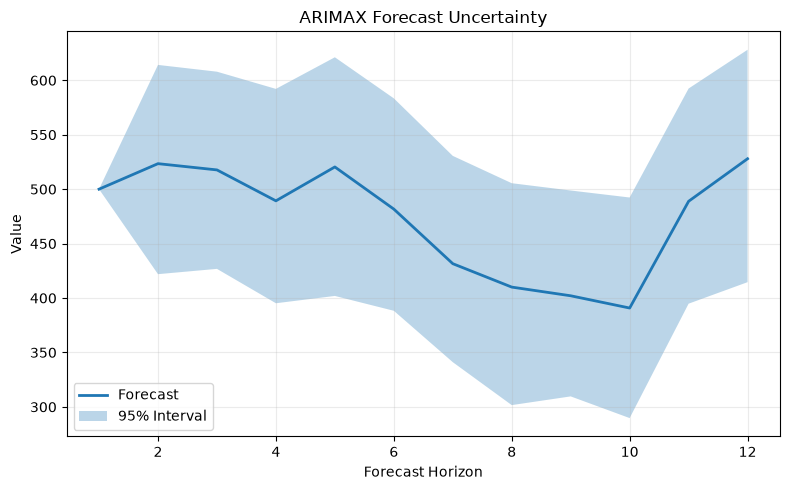

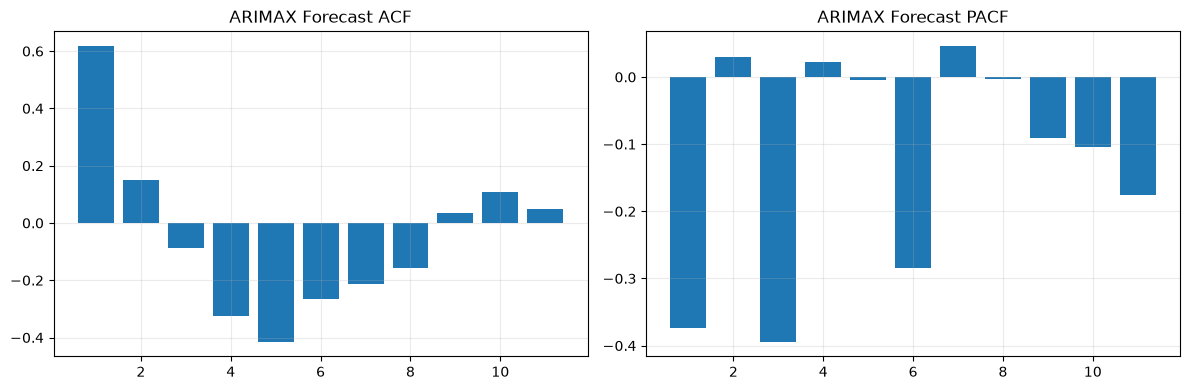

In [75]:
# Generate synthetic precipitation data
monthly_precip =  np.maximum(0, 40 + 30 * np.sin(2 * np.pi * np.arange(15) / 12.0) + Normal(0.0, 15).GenerateRandomValues(15, seed=1234))

#  Time series of streamflow (response) and precipitation (covariate)
flow_ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_flows))
precip_ts = TimeSeries(TimeInterval.OneMonth, start_date, convert_to_dotnet_array(monthly_precip))

ax_model = ARIMAX(flow_ts)     
ax_model.IncludeIntercept=True
ax_model.AROrderP=1
ax_model.DiffOrderD=0
ax_model.MAOrderQ=0
ax_model.UseDefaultTrainingSteps = False
ax_model.XOrderB = 0                # Contemporaneous effect
ax_model.IncludeSeasonality = True  # Capture seasonal patterns
ax_model.TrainingTimeSteps = flow_ts.Count

# Add covariate(s)
covariates = List[TimeSeries]()
covariates.Add(precip_ts)
ax_model.SetCovariates(covariates)

# MLE estimation using MaximumLikelihood class
ax_mle = MaximumLikelihood(ax_model)
ax_mle.Estimate()

if ax_mle.IsEstimated:
    ax_model.SetParameterValues(ax_mle.BestParameterSet.Values)

    # Parameter order depends on model configuration
    # For ARIMAX with intercept, AR(1), seasonality, and 1 covariate:
    # Parameters are ordered: intercept, AR coefficients, seasonal terms, covariate betas, sigma
    print("MLE Estimates:")
    for i in range(ax_model.Parameters.Count):
        print(f"{ax_model.Parameters[i].Name}: {ax_model.Parameters[i].Value:.4f}")

# Bayesian estimation
ax_analysis = ARIMAXAnalysis(ax_model)
ax_analysis.BayesianAnalysis.PRNGSeed = 2727
ax_analysis.BayesianAnalysis.Iterations = 10000
ax_analysis.BayesianAnalysis.WarmupIterations = 5000
ax_analysis.ForecastingTimeSteps = 12 

ax_analysis.RunAsync().Wait()
# Access posterior summaries
ax_results = ax_analysis.BayesianAnalysis.Results

print("\nBayesian Estimates:")
print(f"{"Parameter":<20} {"Mean":>10} {"Std Dev":>10} {"2.5%":>10} {"97.5%":>10}")
for i in range(ax_model.Parameters.Count):
    stats = ax_results.ParameterResults[i].SummaryStatistics
    print(f"{ax_model.Parameters[i].Name:<20} {stats.Mean:>10.4f} {stats.StandardDeviation:>10.4f} " +
                      f"{stats.LowerCI:>10.4f} {stats.UpperCI:>10.4f}")

# Access forecasts with uncertainty
ax_forecasts = ax_analysis.AnalysisResults
print("\nForecasts:")
print(f"{"Month":<8} {"Forecast":>12} {"Lower 95%":>12} {"Upper 95%":>12}")
for h in range(12):
    mode = ax_forecasts.MeanCurve[h]
    # lower = ax_forecasts.LowerCurve[h]           these don't exist??
    # upper = ax_forecasts.UpperCurve[h]
    lower = ax_forecasts.ConfidenceIntervals[h, 1]      # need to double check definition of these....
    upper = ax_forecasts.ConfidenceIntervals[h, 2]
    print(f"{h + 1:<8} {mode:>12.1f} {lower:>12.1f} {upper:>12.1f}")

ax_forecast_steps = np.arange(1,ax_analysis.ForecastingTimeSteps + 1)

ax_forecast_mode = np.array([
    ax_forecasts.MeanCurve[i]
    for i in range(
        ax_analysis.ForecastingTimeSteps
    )
])

ax_forecast_lower = np.array([
    ax_forecasts.ConfidenceIntervals[i,1]
    for i in range(
        ax_analysis.ForecastingTimeSteps
    )
])

ax_forecast_upper = np.array([
    ax_forecasts.ConfidenceIntervals[i,2]
    for i in range(
        ax_analysis.ForecastingTimeSteps
    )
])

plt.figure(figsize=(8,5))

plt.plot(ax_forecast_steps,ax_forecast_mode,linewidth=2,label="Forecast")
plt.fill_between(ax_forecast_steps,ax_forecast_lower,ax_forecast_upper,alpha=0.3,label="95% Interval")
plt.xlabel("Forecast Horizon")
plt.ylabel("Value")
plt.title("ARIMAX Forecast Uncertainty")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()

# Add ACF and PACF graph?
ax_acf = Autocorrelation.Function(convert_to_dotnet_array(ax_forecast_mode),lagMax=12)
ax_pacf = Autocorrelation.Function(convert_to_dotnet_array(ax_forecast_mode),lagMax=12,type=Autocorrelation.Type.Partial)
lags = np.arange(1,12)

ax_acf_vals = np.array([
    float(ax_acf[int(i),1])
    for i in lags
])

ax_pacf_vals = np.array([
    float(ax_pacf[int(i),1])
    for i in lags
])

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].bar(lags,ax_acf_vals)
ax[0].set_title("ARIMAX Forecast ACF")
ax[0].grid(alpha=0.25)

ax[1].bar(lags,ax_pacf_vals)
ax[1].set_title("ARIMAX Forecast PACF")
ax[1].grid(alpha=0.25)

plt.tight_layout()


## Review: Bayesian Estimation

As we've seen in our examples, all the time series models in BestFit support Bayesian MCMC estimation through their corresponding analysis classes. Bayesian estimation provides complete uncertainty quantification — not just point estimates, but full probability distributions for parameters and forecasts [[4]](#4). Recall that MLE gives you the "best" parameter values, but doesn't tell you how uncertain those estimates are. Bayesian estimation provides parameter uncertainty, forecast uncertainty, probabilistic inference, and prior incorporation.

BestFit uses weakly informative default priors:

| Parameter | Default Prior | Rationale |
|-----------|--------------|-----------|
| $\mu$ | $\text{Uniform}(L_\mu, U_\mu)$ | Bounds from data range |
| $\phi_i$ | $\text{Uniform}(-2, 2)$ | Allows non-stationary exploration |
| $\theta_j$ | $\text{Uniform}(-2, 2)$ | Allows non-invertible exploration |
| $\sigma$ | $\text{Uniform}(\epsilon, U_\sigma)$ | Positive scale parameter |

As always we should check MCMC convergence before using results [[4]](#4). We check the ARIMAX model parameters as an example.

In [76]:
ax_results = ax_analysis.BayesianAnalysis.Results

print(f"{"Parameter":<20} {"R-hat":>8} {"ESS":>8} {"Converged?":>12}")
for i in range(ax_model.Parameters.Count):
    stats = ax_results.ParameterResults[i].SummaryStatistics
    converged = stats.Rhat < 1.1 and stats.ESS > 100

    print(f"{ax_model.Parameters[i].Name:<20} {stats.Rhat:>8.3f} {stats.ESS:>8.0} {"Yes" if converged else "No":>12}")

Parameter               R-hat      ESS   Converged?
Intercept (μ)           1.025    4e+02          Yes
Seasonality Sin (ψ₁)    1.000    5e+03          Yes
Seasonality Cos (ψ₂)    1.000    2e+03          Yes
Covariate (β₁)          1.000    6e+03          Yes
AR (φ₁)                 1.002    9e+02          Yes
Scale (σ)               1.001    1e+03          Yes


Diagnostic thresholds:
- R-hat (Gelman-Rubin): Should be < 1.1 (preferably < 1.05)
- ESS (Effective Sample Size): Should be > 100 for reliable inference

## Model Diagnostics

Fitting a model is only the beginning. Proper diagnostics verify that the model adequately captures the data structure.

### Residual Analysis

If the model is correctly specified, residuals should be white noise. This means the residuals should look purely random with no structure.

Residual mean: -0.4270 (should be ≈ 0)
Residual std:  57.1929 (should be ≈ σ = 58.0729)


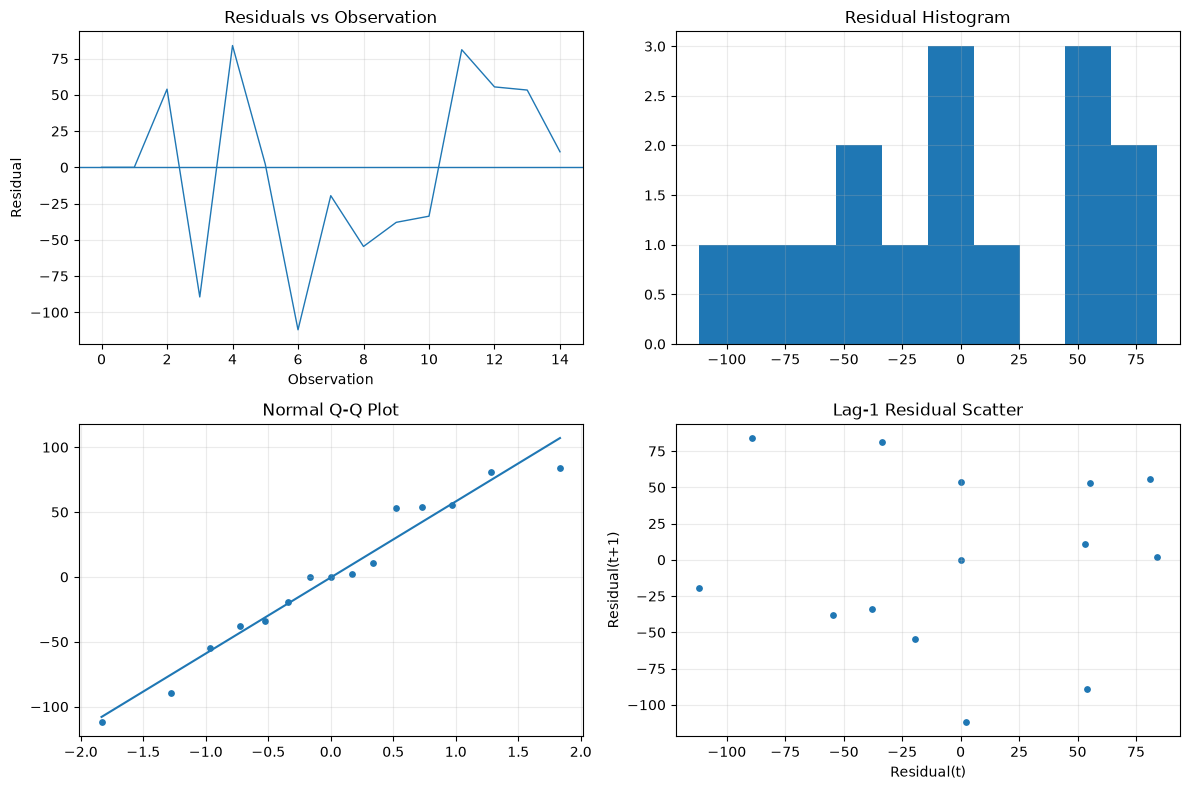

In [77]:
ar_map_params = ar_analysis.BayesianAnalysis.Results.MAP.Values
ar_residuals = ar_model.Residuals(ar_map_params)

# Check residual statistics
mean = np.mean(ar_residuals)
variance = sum(r * r for r in ar_residuals) / len(ar_residuals) - mean * mean

# Get sigma from the last parameter (always the scale parameter)
sigma = ar_map_params[-1]

print(f"Residual mean: {mean:.4f} (should be ≈ 0)")
print(f"Residual std:  {math.sqrt(variance):.4f} (should be ≈ σ = {sigma:.4f})")

residual_array = np.array([float(r) for r in ar_residuals])

fig, ax = plt.subplots(2,2,figsize=(12, 8))

ax[0,0].plot(residual_array, linewidth=1)
ax[0,0].axhline(0.0, linewidth=1)
ax[0,0].set_title("Residuals vs Observation")
ax[0,0].set_xlabel("Observation")
ax[0,0].set_ylabel("Residual")
ax[0,0].grid(alpha=0.25)

ax[0,1].hist(residual_array)
ax[0,1].set_title("Residual Histogram")
ax[0,1].grid(alpha=0.25)

ordered = np.sort(residual_array)
probs = (np.arange(1, len(ordered)+1) - 0.5) / len(ordered)
normal_ref = Normal(0, 1)
theoretical = np.array([ normal_ref.InverseCDF(float(p)) for p in probs])
ax[1,0].scatter(theoretical,ordered,s=15)

coef = np.polyfit(theoretical,ordered,1)
ax[1,0].plot(theoretical, coef[0] * theoretical + coef[1])
ax[1,0].set_title("Normal Q-Q Plot")
ax[1,0].grid(alpha=0.25)

ax[1,1].scatter(residual_array[:-1],residual_array[1:],s=15)
ax[1,1].set_title("Lag-1 Residual Scatter")
ax[1,1].set_xlabel("Residual(t)")
ax[1,1].set_ylabel("Residual(t+1)")
ax[1,1].grid(alpha=0.25)

plt.tight_layout()

### ACF of Residuals

Residuals should show no significant autocorrelation:

Lag    ACF
  1   -0.010 
  2    0.072 
  3    0.117 
  4   -0.250 
  5   -0.265 
  6   -0.206 
  7    0.035 
  8   -0.112 
  9    0.081 
 10   -0.016 
 11    0.040 
 12    0.013 
 13    0.001 
 14    0.000 
 15    0.000 
 16    0.000 
 17    0.000 
 18    0.000 
 19    0.000 
 20    0.000 


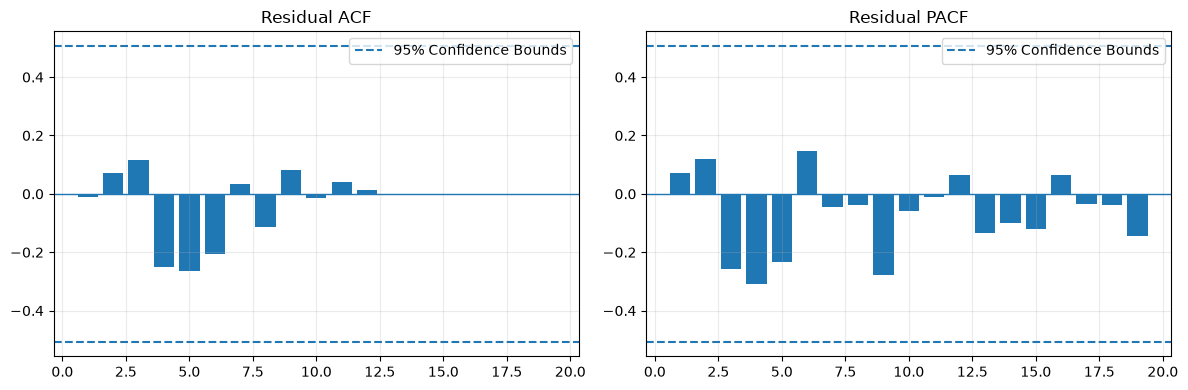

In [78]:
# Compute residual autocorrelations
residual_acf = Autocorrelation.Function(ar_residuals, lagMax=20)  # BestFit technical ref docs uses diff autocorrelation function...

print("Lag    ACF")
bound = 1.96 / math.sqrt(len(ar_residuals)) # 95% confidence bound
for i in range(1,21):
    sig = " *" if np.abs(residual_acf[i,1]) > bound else ""
    print(f"{i:>3}  {residual_acf[i,1]:>7.3f} {sig}")

lags = np.arange(1,20)

acf_vals = np.array([
    float(residual_acf[int(i),1])
    for i in lags
])

pacf = Autocorrelation.Function(ar_residuals,lagMax=20,type=Autocorrelation.Type.Partial)

pacf_vals = np.array([
    float(pacf[int(i),1])
    for i in lags
])

fig, ax = plt.subplots(1,2,figsize=(12,4))

ax[0].bar(lags,acf_vals)
ax[0].axhline(bound,linestyle="--", label="95% Confidence Bounds")
ax[0].axhline(-bound,linestyle="--", label="_nolegend_")
ax[0].axhline(0.0,linewidth=1)
ax[0].set_title( "Residual ACF")
ax[0].grid(alpha=0.25)
ax[0].legend()

ax[1].bar(lags,pacf_vals)
ax[1].axhline(bound,linestyle="--", label="95% Confidence Bounds")
ax[1].axhline(-bound,linestyle="--", label="_nolegend_")
ax[1].axhline(0.0,linewidth=1)
ax[1].set_title("Residual PACF")
ax[1].grid(alpha=0.25)
ax[1].legend()

plt.tight_layout()

Significant autocorrelation (marked with `*`) suggests the model is missing structure. Consider:
- Increasing AR or MA order
- Adding seasonal terms
- Checking for outliers or structural breaks

### Ljung-Box Test

The Ljung-Box test formally tests for residual autocorrelation:

$$
Q = n(n+2) \sum_{h=1}^{H} \frac{\hat{\rho}(h)^2}{n-h}
$$

Under the null hypothesis of no autocorrelation, $Q \sim \chi^2_{H-p-q}$.

In [79]:
# Ljung-Box test  for autocorrelation
lb = HypothesisTests.LjungBoxTest(ar_residuals)      # This is different than BestFit tech ref docs... this also should return p-val directly

print(f"Ljung-Box p-value: {lb:.4f}")

if lb < 0.05: 
    print("Warning: Significant residual autocorrelation") 
else: 
    print("✓ No significant autocorrelation")


Ljung-Box p-value: 0.8902
✓ No significant autocorrelation


### Normality Check

Residuals should be approximately normally distributed:

In [80]:
# Jarque-Bera test for normality
jb = HypothesisTests.JarqueBeraTest(ar_residuals)  # This is different than BestFit tech ref docs... this also should return p-val directly
print(f"Jarque-Bera p-value: {jb:.4f}")

if jb < 0.05:
    print("Warning: Residuals may not be normally distributed")
else:
    print("✓ Residuals appear to be normally distributed")

Jarque-Bera p-value: 0.8013
✓ Residuals appear to be normally distributed


Non-normality may indicate:
- Outliers (high kurtosis)
- Asymmetric shocks (non-zero skewness)
- Need for transformation (log, Box-Cox)


## Data Transformations

Many hydrologic variables (streamflow, precipitation, concentrations) are positively skewed with variance that increases with the mean. Transformations can stabilize variance and improve normality.

### Available Transformations

| Transform | Formula | Inverse | Use Case |
|-----------|---------|---------|----------|
| None | $Y_t^* = Y_t$ | $Y_t = Y_t^*$ | Data already Gaussian |
| Logarithmic | $Y_t^* = \log(Y_t)$ | $Y_t = \exp(Y_t^*)$ | Positive, right-skewed data |
| Box-Cox | $Y_t^* = \frac{Y_t^\lambda - 1}{\lambda}$ | $Y_t = (\lambda Y_t^* + 1)^{1/\lambda}$ | General power transform |

### Logarithmic Transformation

The most common transformation for hydrologic data:

In [81]:
log_model = AutoRegressive(ts, order=2, TransformType = Transform.Logarithmic)

Interpretation: The model is fit in log-space, so AR coefficients describe multiplicative dynamics. A forecast of $\hat{Y}^*_{t+1}$ in log-space corresponds to $\exp(\hat{Y}^*_{t+1})$ in original units.

**Warning:** Requires all values to be positive. Add a small constant if zeros are present.

### Box-Cox Transformation

The Box-Cox family includes log ($\lambda = 0$) and square root ($\lambda = 0.5$) as special cases:

$$
Y_t^* = \begin{cases}
\frac{Y_t^\lambda - 1}{\lambda} & \lambda \neq 0 \\
\log(Y_t) & \lambda = 0
\end{cases}
$$

In [82]:
box_model = AutoRegressive(ts, order= 2, TransformType = Transform.BoxCox)
box_model.SetTransformParameters(lambda1=0.5);  # Square root transform


### Jacobian Adjustment

When using transformations, the likelihood must include the log-Jacobian for proper inference. For Box-Cox:

$$
\log J = \sum_{t=1}^{n} (\lambda - 1) \log|Y_t|
$$

BestFit handles this automatically.

## Model Selection

Choosing the right model orders (p, d, q) is both art and science. Here's a systematic approach.

### The Box-Jenkins Methodology

The classic approach [[1]](#1):

1. Identification: Use ACF/PACF patterns to guess orders
2. Estimation: Fit the model
3. Diagnostics: Check residuals
4. Refinement: Adjust orders if diagnostics fail

### ACF/PACF Patterns

| Pattern | Suggested Model |
|---------|-----------------|
| ACF: exponential decay; PACF: cuts off at $p$ | AR(p) |
| ACF: cuts off at $q$; PACF: exponential decay | MA(q) |
| ACF: exponential decay; PACF: exponential decay | ARMA(p,q) |
| ACF: very slow decay | Differencing needed (ARIMA) |

### Information Criteria

Compare models using penalized likelihood:

- AIC: $-2\ell(\hat{\theta}) + 2k$ — favors predictive accuracy
- BIC: $-2\ell(\hat{\theta}) + k\log(n)$ — stronger penalty, favors parsimony

Lower values are better. BIC typically selects simpler models than AIC.

In [83]:
# Compare AR(1), AR(2), AR(3)
results = []

for p in [1, 2, 3 ]:
    model = AutoRegressive(ts, order=p, includeIntercept=True)
    model.UseDefaultTrainingSteps = False

    model.TrainingTimeSteps = ts.Count
    mle = MaximumLikelihood(model)
    mle.Estimate()
    model.SetParameterValues(mle.BestParameterSet.Values)

    

    k = p + 2           # Number of parameters
    n = ts.Count - p    # Effective sample size
    logLik = model.DataLogLikelihood([p.Value for p in model.Parameters])

    aic = mle.GetAIC()      # Diff than BestFit tech ref doc
    bic = mle.GetBIC(len(ts))

    results.append((p, aic, bic))
    print(f"AR({p}): AIC = {aic:.1f}, BIC = {bic:.1f}")

bestAIC = min(results, key=lambda r: r[1])
bestBIC = min(results, key=lambda r: r[2])

print(f"\nBest by AIC: AR({bestAIC[0]})")
print(f"Best by BIC: AR({bestBIC[0]})")

AR(1): AIC = 160.1, BIC = 162.2
AR(2): AIC = 151.9, BIC = 154.8
AR(3): AIC = 143.0, BIC = 146.5

Best by AIC: AR(3)
Best by BIC: AR(3)


### Practical Guidelines

| Scenario | Recommendation |
|----------|---------------|
| Stationary series, gradual ACF decay | Start with AR(1) or AR(2) |
| Stationary series, sharp ACF cutoff | Try MA(1) or MA(2) |
| Trending series | Difference first (ARIMA with d=1) |
| Seasonal patterns | Use ARIMAX with `IncludeSeasonality = true` |
| External predictors available | Use ARIMAX |
| Uncertain about order | Prefer parsimony — simpler models often forecast better |

## Summary
In this notebook you:   
$\checkmark$ Learned how to intialize TimeSeries objects            
$\checkmark$ Built a BlockSeries in a DataFrame     
$\checkmark$ Explored core concepts of time series analysis     
$\checkmark$ Built BestFit's 4 major time series models     
$\checkmark$ Validated time series models       
$\checkmark$ Learned how to transform data to improve model accuracy        

## Exercises
1. Compare `(p,q)=(1,1)` vs `(2,1)`.
2. Turn on differencing for nonstationary variants.
3. Add external covariates and nonzero `XOrderB`.

## References
<a id="1">[1]</a>
G. E. P. Box, G. M. Jenkins, G. C. Reinsel, and G. M. Ljung, *Time Series Analysis: Forecasting and Control*, 5th ed., Hoboken, NJ: Wiley, 2015.

<a id="2">[2]</a>
P. J. Brockwell and R. A. Davis, *Introduction to Time Series and Forecasting*, 3rd ed., New York: Springer, 2016.

<a id="3">[3]</a>
J. D. Hamilton, *Time Series Analysis*, Princeton, NJ: Princeton University Press, 1994.

<a id="4">[4]</a>
A. Gelman, J. B. Carlin, H. S. Stern, D. B. Dunson, A. Vehtari, and D. B. Rubin, *Bayesian Data Analysis*, 3rd ed., Boca Raton, FL: Chapman and Hall/CRC, 2013.